# DC Bike Safety Map: Data Processing

This notebook takes [road](https://opendata.dc.gov/datasets/DCGIS::roadway-block/about) and [crash](https://opendata.dc.gov/datasets/crashes-in-dc/about) data from the DC data website and processes it for the [DC Bike Safety Map](http://161.35.142.176/). The LTS and ridescore build on 01_lts_osm_elia_v2.ipynb.

This is preliminary work and future work could include:
* see if same data can be extracted from OSM
* Taking directionality of road into account
* Adding bike trails
* Implement standard LTS methodology
* Refine scaling factors to 0 to 100 scale

In [1]:
# 1) Imports + settings
import warnings, math, re, os, json

import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString, MultiLineString, Point
import osmnx as ox
import folium
from folium.plugins import MeasureControl
import requests
import matplotlib.pyplot as plt
import numpy as np

import requests

import time
from datetime import date
from dateutil.relativedelta import relativedelta

ox.settings.use_cache = True
ox.settings.log_console = False

print("Versions →", 
      "osmnx", ox.__version__, 
      "| geopandas", gpd.__version__)

Versions → osmnx 2.0.7 | geopandas 1.1.2


## Road Data

In [19]:
# 2) Get Roadblock data from website
CRS = 'EPSG:4326'
def try_fetch_dc_roads():
    url = "https://opendata.arcgis.com/datasets/DCGIS::roadway-block.geojson"
    try:
        print('trying website')
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        print(r)
        print(url)
        if r.ok:
            gj = r.json()
            roads = gpd.GeoDataFrame.from_features(gj["features"], crs=CRS)
            return roads
    except Exception as error:
        print('Error reading road data from dc gov website')

edges = try_fetch_dc_roads()
edges.to_file('edges.geojson')
edges

trying website
<Response [200]>
https://opendata.arcgis.com/datasets/DCGIS::roadway-block.geojson


,geometry,ROUTEID,FROMMEASURE,TOMEASURE,ROUTENAME,ROADTYPE,BLOCKKEY,TOTALTRAVELLANES,TOTALPARKINGLANES,TOTALRAISEDBUFFERS,...,PARKINGZONE_RPP,AADT_COMBINATION,AADT_COMBINATION_YEAR,AADT_SINGLE_UNIT,AADT_SINGLE_UNIT_YEAR,DC_MAINTENANCE_OPERATIONS,MAINTENANCE_OPERATIONS,VERTICAL_DEFLECTION,OBJECTID,SHAPELEN
0,"LINESTRING Z (-77.06513 38.95849 0, -77.06519 ...",11064022,0.000000,80.945198,NEVADA AVE NW,1,d70b65e6ea22f0071f19cf09d5553717,2,2,0,...,None,NaN,NaN,NaN,NaN,1,1.0,None,4031409,0
1,"LINESTRING Z (-77.02599 38.90725 0, -77.02599 ...",11001002,1682.673950,1830.726562,10TH ST NW,1,528f6e548b149fa21ae83561cdc63dae,1,2,0,...,1,15.0,2020.0,31.0,2020.0,1,1.0,None,4031410,0
2,"LINESTRING Z (-77.0179 38.9141 0, -77.01801 38...",11064282,2537.775879,2602.471924,NEW JERSEY AVE NW,1,05124d80213b35ef82e5b47e5b017084,4,0,0,...,None,101.0,2020.0,432.0,2020.0,1,1.0,None,4031411,0
3,"LINESTRING Z (-77.01481 38.9385 0, -77.0145 38...",11057932,0.000000,120.393799,MACARTHUR DR NW,1,89a29f6d9a6d16994604fb73fd88dea8,2,0,0,...,None,NaN,NaN,NaN,NaN,11,74.0,None,4031412,0
4,"LINESTRING Z (-77.02378 38.93282 0, -77.0238 3...",11040042,1846.154175,1869.230347,GEORGIA AVE NW,1,9294a0e372f55c25c7fd7e47bb61c7ab,4,2,0,...,None,166.0,2020.0,580.0,2020.0,1,1.0,None,4031413,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13833,"LINESTRING Z (-76.99091 38.83236 0, -76.99084 ...",13013262,491.352692,666.291809,BARNABY ST SE,1,831193e3c6319eeffcd4b450bdd2d3dd,2,2,0,...,2,NaN,NaN,NaN,NaN,1,1.0,YES,4064250,0
13834,"LINESTRING Z (-76.98831 38.88146 0, -76.98831 ...",13001302,925.651916,1167.683838,13TH ST SE,1,a1789777713c61fa6aa73fb581afbed0,2,3,0,...,3,NaN,NaN,NaN,NaN,1,1.0,None,4064251,0
13835,"LINESTRING Z (-76.9815 38.84737 0, -76.98145 3...",13084782,105.780403,192.215302,TANNER ST SE,1,f286b3f4bca7b6e81a3918ad7afe539e,2,2,0,...,None,NaN,NaN,NaN,NaN,1,1.0,None,4064252,0
13836,"LINESTRING Z (-76.99845 38.88128 0, -76.99835 ...",13038612,311.641998,508.683807,G ST SE,1,5fb6a403d1ca5c8c54a76e6273dc14a8,2,2,0,...,1,NaN,NaN,NaN,NaN,1,1.0,None,4064253,0


In [15]:
#look at columns
for c in gdf.columns:
    print(c)

geometry
ROUTEID
FROMMEASURE
TOMEASURE
ROUTENAME
ROADTYPE
BLOCKKEY
TOTALTRAVELLANES
TOTALPARKINGLANES
TOTALRAISEDBUFFERS
TOTALTRAVELLANEWIDTH
TOTALCROSSSECTIONWIDTH
TOTALPARKINGLANEWIDTH
TOTALRAISEDBUFFERWIDTH
TOTALTRAVELLANESINBOUND
TOTALTRAVELLANESOUTBOUND
TOTALTRAVELLANESBIDIRECTIONAL
TOTALTRAVELLANESREVERSIBLE
SUMMARYDIRECTION
BIKELANE_PARKINGLANE_ADJACENT
BIKELANE_THROUGHLANE_ADJACENT
BIKELANE_POCKETLANE_ADJACENT
BIKELANE_CONTRAFLOW
BIKELANE_CONVENTIONAL
BIKELANE_DUAL_PROTECTED
BIKELANE_PROTECTED
BIKELANE_BUFFERED
DOUBLEYELLOW_LINE
SECTIONFLAGS
LOC_ERROR
MIDMEASURE
AADT
AADT_YEAR
FHWAFUNCTIONALCLASS
HPMSID
HPMSSECTIONTYPE
ID
IRI
IRI_DATE
NHSCODE
OWNERSHIP
PCI_CONDCATEGORY
PCI_LASTINSPECTED
PCI_SCORE
QUADRANT
SIDEWALK_IB_PAVTYPE
SIDEWALK_IB_WIDTH
SIDEWALK_OB_PAVTYPE
SIDEWALK_OB_WIDTH
SPEEDLIMITS_IB
SPEEDLIMITS_IB_ALT
SPEEDLIMITS_OB
SPEEDLIMITS_OB_ALT
STREETNAME
STREETTYPE
BLOCK_NAME
ADDRESS_RANGE_HIGH
ADDRESS_RANGE_LOW
ADDRESS_RANGE_RIGHT_HIGH
ADDRESS_RANGE_LEFT_HIGH
ADDRESS_RANGE_

In [21]:
# 3) Helpers for tag parsing
def classify_facility(tags):
    # standardize bike lane types into 3 categories (protected, buffered, and painted). Sharrows don't seem to be indicated in dataset
    # directionality of road is not taken into account
    if (tags.get("BIKELANE_PROTECTED") in {"IB", "OB", "BD"}) or (tags.get("BIKELANE_DUAL_PROTECTED") in {"IB", "OB", "BD"}):
        return "protected_track"
    elif (tags.get("BIKELANE_BUFFERED") in {"IB", "OB", "BD"}):
        return "buffered_lane"
    elif (tags.get("BIKELANE_CONVENTIONAL") in {"IB", "OB", "BD"}):
        return "painted_lane"
    else:
        return "none"

#replace function number with name
function_dict = {11: 'Interstate', 12: 'Other Freeway and Expressway', 14:  'Principal/Primary Arterial', 16:  'Minor Arterial', 17:  'Collector', 19:'Local'}
def name_function(tags):
    if tags['DCFUNCTIONALCLASS'] in function_dict.keys():
        return function_dict[tags['DCFUNCTIONALCLASS']]
    else:
        return 'Other'



In [22]:
# 3) simplify and impute fields as needed.
# while the safety scores my included the impute values to ensure it processes without error, the raw values are displayed on the map.

rows = []
for i, r in edges.reset_index(drop=True).iterrows():
    if (i%1000) == 0:
        print(i)
    tags = r.to_dict()
    facility = classify_facility(tags)
    function = name_function(tags)
    rows.append({
        "route_id": tags['ROUTEID'],
        "route_name": tags['ROUTENAME'],
        "function": function,
        "num_lanes": tags['TOTALTRAVELLANES'] if tags['TOTALTRAVELLANES'] >-1 else 1, #set number of travels to 1 if no value is available 
        "num_lanes_raw": tags['TOTALTRAVELLANES'],
        "speed_limit": tags['SPEEDLIMITS_OB'] if tags['SPEEDLIMITS_OB'] >1 else 25, #speed limit is set to 25 is no values is available
        "speed_limit_raw": tags['SPEEDLIMITS_OB'],
        "bike_facility_type": facility,
        "parking_presence": True if tags["TOTALPARKINGLANES"] > 0 else False,
        "road_width": tags['TOTALCROSSSECTIONWIDTH'],
        "slow_street": tags['SLOWSTREETINFO'],
        "pavement_condition": tags['PCI_CONDCATEGORY'],
        "geometry": r.geometry
    })

gdf = gpd.GeoDataFrame(rows, geometry="geometry", crs=CRS)
print("Normalized segments:", len(gdf))
gdf.head(2)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
Normalized segments: 13838


,route_id,route_name,function,num_lanes,num_lanes_raw,speed_limit,speed_limit_raw,bike_facility_type,parking_presence,road_width,slow_street,pavement_condition,geometry
0,11064022,NEVADA AVE NW,Collector,2,2,20.0,20.0,none,True,33,None,Excellent,"LINESTRING Z (-77.06513 38.95849 0, -77.06519 ..."
1,11001002,10TH ST NW,Collector,1,1,25.0,NaN,painted_lane,True,31,None,Excellent,"LINESTRING Z (-77.02599 38.90725 0, -77.02599 ..."


### Modified Level of Traffic Stress score

We use our own, modified level of traffic stress (LTS) calculator.

<table>
  <tbody>
    <tr>
      <th>Bike lane</th>
      <th>Number of lanes</th>
      <th>Speed limit</th>
      <th>Road function</th>
      <th>LTS</th>
    </tr>
    <tr style="background-color: #a4f1b6;">
      <td>Protected track</td>
      <td>-</td>
      <td>-</td>
      <td>-</td>
      <td>1</td>
    <tr style="background-color: #f7f08c;">
      <td>Buffered lane or painted lane</td>
      <td>&lt;= 2</td>
      <td>&lt;= 25</td>
      <td>-</td>
      <td>2</td>
    </tr>
    <tr style="background-color: #f7f08c;">
      <td>None</td>
      <td>&lt;= 2</td>
      <td>&lt;= 25</td>
      <td>Local</td>
      <td>2</td>
    </tr>
    <tr style="background-color: #f0c77b;">
      <td>Buffered lane or painted lane</td>
      <td>&gt;2 and &lt;=3</td>
      <td>&gt;25 and &lt;= 30</td>
      <td>-</td>
      <td>3</td>
    </tr>
    <tr style="background-color: #f0c77b;">
      <td>None</td>
      <td>&lt;=2</td>
      <td>&gt;25 and &lt;= 30</td>
      <td>Local</td>
      <td>3</td>
    </tr>
    <tr style="background-color: #e47d86;">
      <td colspan="4">Any other combination</td>
      <td>4</td>
    </tr>
  </tbody>
</table>

In [25]:
# 4) LTS rules (compact + tunable)

def lts_level(facility, speed, lanes, function=""):
    hw = (function or "").lower()
    if facility in {"protected_track"}: return 1 # or hw in {"cycleway","path"}: return 1, also include ,"separated_lane" here
    if facility in {"buffered_lane","painted_lane"}:
        if speed <= 25 and lanes <= 2: return 2
        if speed <= 30 and lanes <= 3: return 3
        return 4
    if facility in {"none"}: #include "shared" here
        if speed <= 20 and lanes <= 2 and hw in {"local"}: 
            return 2
        if speed <= 30 and lanes <= 2 and hw in {"local"}: return 3
        return 4
    return 4

gdf["lts_level"] = gdf.apply(lambda r: lts_level(r.bike_facility_type, int(r.speed_limit), int(r.num_lanes), r.function), axis=1)
gdf["lts_level"].value_counts().sort_index()

lts_level
1     285
2    7564
3    1606
4    4383
Name: count, dtype: int64

### Data exploration
Let's look at some of the columns of interest

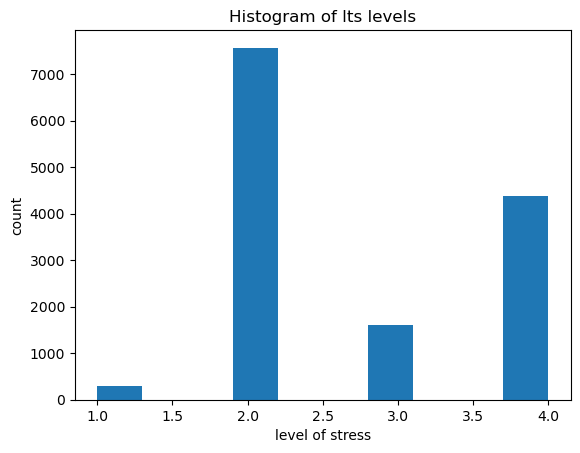

In [31]:
plt.hist(gdf['lts_level'])
plt.xlabel('level of stress')
plt.ylabel('count')
plt.title('Histogram of lts levels')
plt.show()

In [37]:
#change crs to get length in meters
gdf = gdf.to_crs(gdf.estimate_utm_crs())
gdf['len'] = gdf.length
print("length of road network: {:.2f}km".format(sum(gdf['len'])/1000))

length of road network: 1899.29km


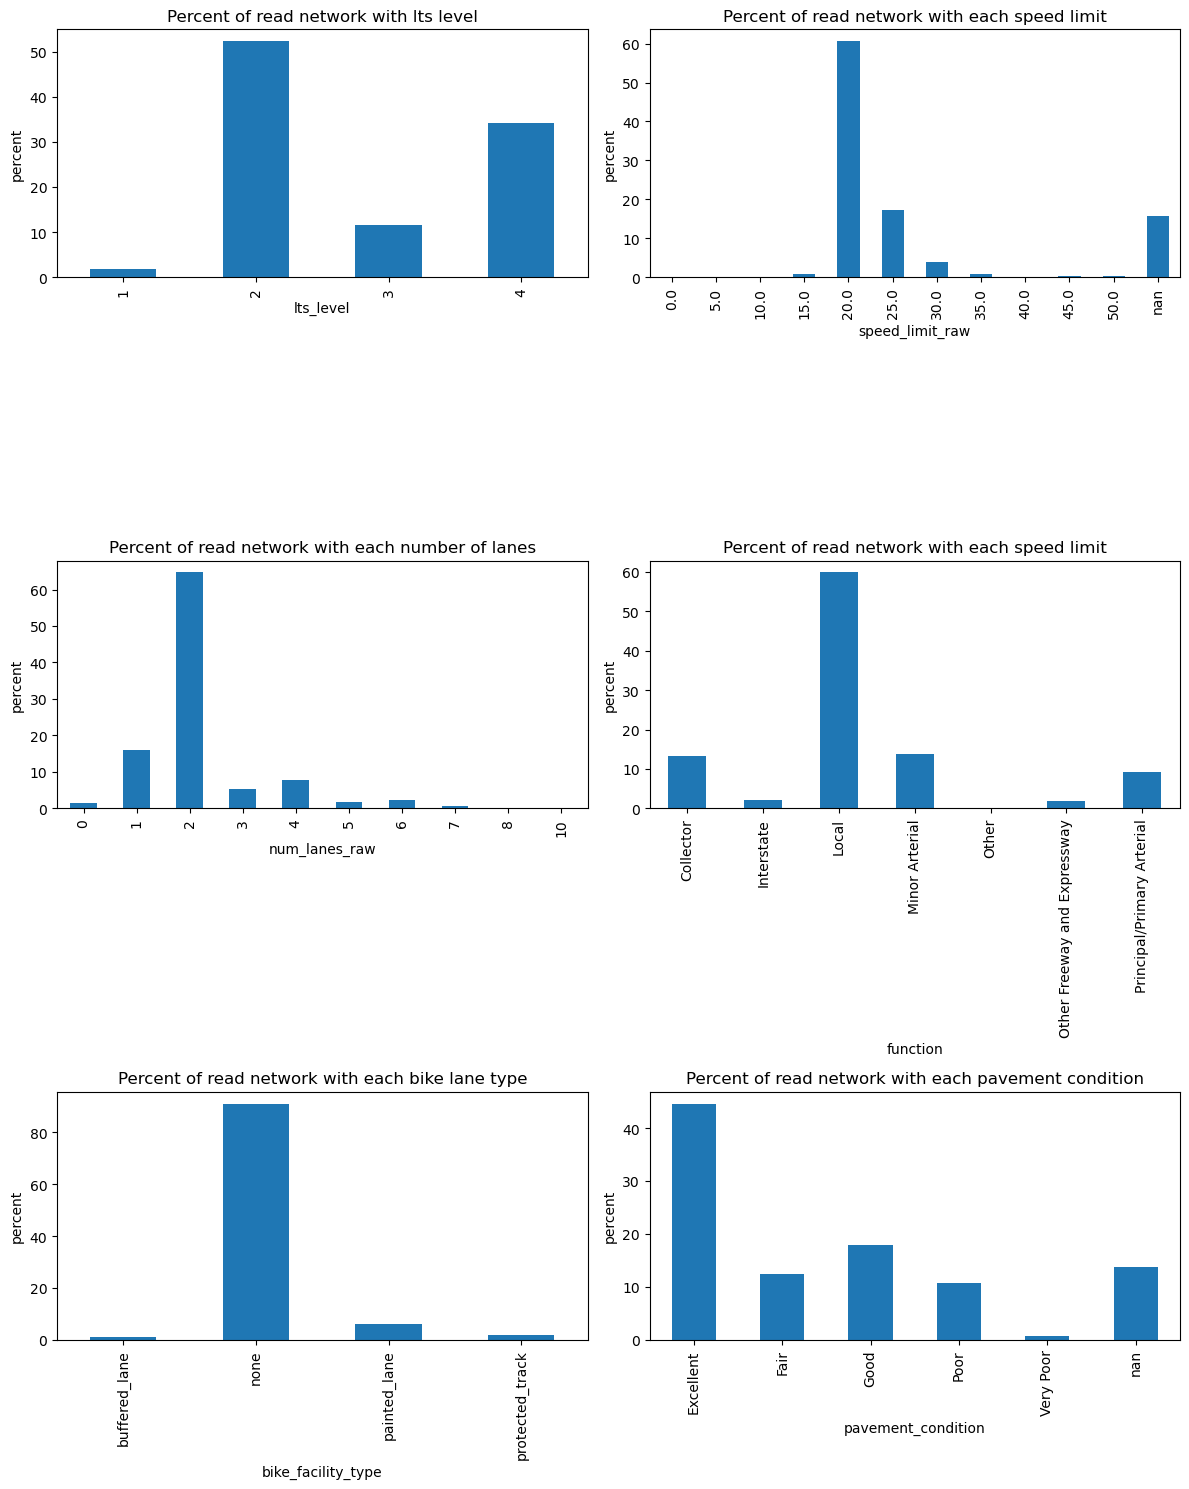

In [69]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15))


sp = gdf.groupby('lts_level', dropna=False)['len'].sum()/gdf['len'].sum()*100
sp.plot(kind='bar', title = 'Percent of read network with lts level', ylabel = 'percent', ax=axes[0,0])

sp = gdf.groupby('speed_limit_raw', dropna=False)['len'].sum()/gdf['len'].sum()*100
sp.plot(kind='bar', title = 'Percent of read network with each speed limit', ylabel = 'percent', ax=axes[0,1])

sp = gdf.groupby('num_lanes_raw', dropna=False)['len'].sum()/gdf['len'].sum()*100
sp.plot(kind='bar', title = 'Percent of read network with each number of lanes', ylabel = 'percent', ax=axes[1,0])

sp = gdf.groupby('function', dropna=False)['len'].sum()/gdf['len'].sum()*100
sp.plot(kind='bar', title = 'Percent of read network with each speed limit', ylabel = 'percent', ax=axes[1,1])

sp = gdf.groupby('bike_facility_type', dropna=False)['len'].sum()/gdf['len'].sum()*100
sp.plot(kind='bar', title = 'Percent of read network with each bike lane type', ylabel = 'percent', ax=axes[2,0])

sp = gdf.groupby('pavement_condition', dropna=False)['len'].sum()/gdf['len'].sum()*100
sp.plot(kind='bar', title = 'Percent of read network with each pavement condition', ylabel = 'percent', ax=axes[2,1])

plt.tight_layout()
plt.show()

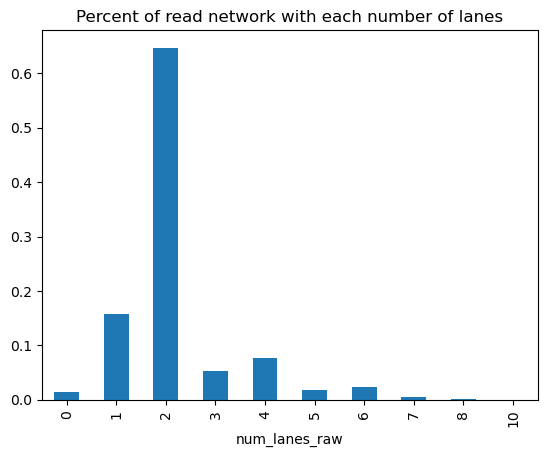

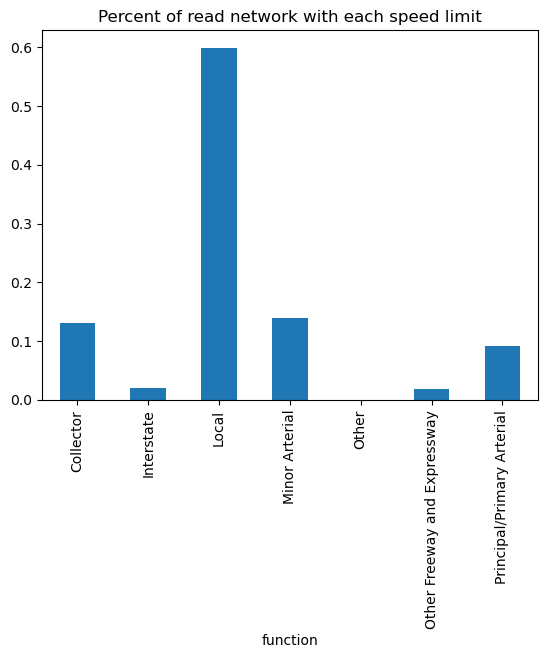

In [70]:
gdf.to_file('levels.geojson')

## Get Crash Data

We only use crashes that resulted in a bicyclist fatality or injury from the last 5 years.

In [5]:
def get_crashes_df(start_date, end_date, chunk_size=1000):
    base_url = "https://maps2.dcgis.dc.gov/dcgis/rest/services/DCGIS_DATA/Public_Safety_WebMercator/MapServer/24/query"

    all_rows = []
    offset = 0

    while True:
        params = {
            "where": (
                f"REPORTDATE >= DATE '{start_date} 00:00:00' "
                f"AND REPORTDATE <= DATE '{end_date} 23:59:59' "
                "AND (MAJORINJURIES_BICYCLIST > 0 "
                "OR MINORINJURIES_BICYCLIST > 0"
                "OR UNKNOWNINJURIES_BICYCLIST > 0"
                "OR FATAL_BICYCLIST > 0)"
            ),
            "outFields": "*",
            "outSR": 4326,
            "f": "json",
            "orderByFields": "OBJECTID",
            "resultOffset": offset,
            "resultRecordCount": chunk_size
        }

        r = requests.get(base_url, params=params, timeout=120)
        data = r.json()

        features = data.get("features", [])

        #print(f"Received {len(features)} features")

        # Extract attribute dictionaries
        for feature in features:
            attrs = feature.get("attributes", {})
            geom = feature.get("geometry")

            if geom and "x" in geom and "y" in geom:
                attrs["geometry"] = Point(geom["x"], geom["y"])
                all_rows.append(attrs)

        # Stop when last page is reached
        if len(features) < chunk_size:
            break

        offset += chunk_size
        print(f"Fetched {offset} records...")
        time.sleep(0.05)

    # Convert to GeoDataFrame
    df = pd.DataFrame(all_rows)
    gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

    return gdf
    
start_date = (date.today()-relativedelta(years=5)).isoformat()
print(start_date)
end_date = date.today().isoformat()
print(end_date)
crashes_new = get_crashes_df(start_date, end_date)
print(len(crashes_new))

2021-03-01
2026-03-01
Fetched 1000 records...
Fetched 2000 records...
2016


In [72]:
# restrict crashes to DC (probably not necessary considering they are coming from DC website)

PLACE_NAME = "Washington, District of Columbia, USA"
CRS = "EPSG:4326"

# Crash join toggles (turn off if ArcGIS blocks)
CRASH_ENABLE = True
YEARS_BACK = 5
CRASH_BUFFER_M = 10

# 3) Area of interest
aoi_gdf = ox.geocode_to_gdf(PLACE_NAME).to_crs(CRS)
aoi = aoi_gdf.geometry.iloc[0]
aoi_gdf

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-77.11979 38.93435, -77.11977 38.934...",-77.119795,38.79163,-76.909366,38.995968,394523734,relation,5396194,38.895037,-77.036543,place,city,16,0.81477,city,Washington,"Washington, District of Columbia, United States"


In [73]:
crashes_new = gpd.overlay(crashes_new, aoi_gdf[["geometry"]], how="intersection")
crashes_new['REPORTDATE_'] = pd.to_datetime(crashes_new["REPORTDATE"], unit="ms", utc=True).dt.tz_convert("America/New_York")
crashes_new

,CRIMEID,CCN,REPORTDATE,ROUTEID,MEASURE,OFFSET,STREETSEGID,ROADWAYSEGID,FROMDATE,TODATE,...,SUBBLOCKKEY,CORRIDORID,NEARESTINTKEY,MAJORINJURIESOTHER,MINORINJURIESOTHER,UNKNOWNINJURIESOTHER,FATALOTHER,OBJECTID,geometry,REPORTDATE_
0,26661162614,21107903,1627946100000,11001402,5579.12,27.28,0.0,0.0,1627947960000,None,...,84073fa307bbfb12d66bc2a398381da5,11001402_2,73435d5fb8f812ed226b15ebaa9a88f0,0.0,0.0,0.0,0.0,445287826,POINT (-77.03273 38.94045),2021-08-02 19:15:00-04:00
1,26667229361,21108380,1628019360000,11003602,2200.33,17.84,NaN,NaN,1628019360000,None,...,104e644e8a45e4f8f5fae8a522dfb492,11003602_6,a38c5c59ffe947cd9e811e4da2f8d5c2,0.0,0.0,0.0,0.0,445288297,POINT (-77.06985 38.94695),2021-08-03 15:36:00-04:00
2,26684719159,21108827,1628092740000,12061162,854.31,44.49,NaN,NaN,1628109120000,None,...,a686015e5346e258d9d532aca3fe0b96,None,0,0.0,0.0,0.0,0.0,445288845,POINT (-76.948 38.89634),2021-08-04 11:59:00-04:00
3,26687496038,21109309,1628163600000,11001402,1537.85,23.44,NaN,NaN,1628167440000,None,...,4ee4ad33be2250ce8d95d389255b3424,11001402_1,f63110cea700e723ffd3d38eb1b4814c,0.0,0.0,0.0,0.0,445288994,POINT (-77.03196 38.90339),2021-08-05 07:40:00-04:00
4,26688187676,21109154,1628124900000,12050892,142.64,45.05,NaN,NaN,1628178660000,None,...,ccf5a699cde70078619692f752acad3c,12050892_1,40736cafb4216780e39074395946fe5a,0.0,0.0,0.0,0.0,445289238,POINT (-77.00742 38.90252),2021-08-04 20:55:00-04:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2004,68550747941,26019716,1771009560000,11051352,729.61,33.43,NaN,NaN,1771032745000,None,...,0ce55da149ac9f9d93607887be614e3f,11051352_1,850091b43e2caa128ef35eaa09d15c69,1.0,0.0,0.0,0.0,445522184,POINT (-77.02581 38.94206),2026-02-13 14:06:00-05:00
2005,68606733635,26021872,1771425900000,Route not found,0.00,0.00,NaN,NaN,1771430609000,None,...,Route not found,Route not found,Route not found,0.0,0.0,0.0,0.0,445522217,POINT (-77.00416 38.90565),2026-02-18 09:45:00-05:00
2006,68674853801,26024422,1771888620000,11001502,3063.72,19.37,NaN,NaN,1771892907000,None,...,f21d99cb604ad1387dbcb38c044fd739,11001502_2,d8d9019d5c5ec0f6fcb972b23e18ba1f,0.0,0.0,0.0,0.0,445522459,POINT (-77.03454 38.91578),2026-02-23 18:17:00-05:00
2007,68649039564,26023593,1771719600000,12015342,36.37,27.42,NaN,NaN,1771730973000,None,...,5e6c7d2133356808243f92a44b320ac8,12015342_1,04eab17816b0ebe7fe88f4688908ed7c,0.0,0.0,0.0,0.0,445522523,POINT (-76.98303 38.90007),2026-02-21 19:20:00-05:00


In [74]:
crashes_new.to_file('crashes_dcdata.geojson')

In [76]:
keep_columns = ['REPORTDATE_', 'ADDRESS', 'MAJORINJURIES_BICYCLIST', 'MINORINJURIES_BICYCLIST', 'UNKNOWNINJURIES_BICYCLIST','FATAL_BICYCLIST', 'TOTAL_BICYCLES', 'BICYCLISTSIMPAIRED', 'TOTAL_VEHICLES', 'TOTAL_PEDESTRIANS', 'geometry']
crashes_reduced = crashes_new[keep_columns]
crashes_reduced.to_file('crashes_reduced.geojson')

In [81]:
print('number of injuries and fatalities in the last 5 years:')
inj = ['MAJORINJURIES_BICYCLIST', 'MINORINJURIES_BICYCLIST', 'UNKNOWNINJURIES_BICYCLIST','FATAL_BICYCLIST']
total= 0
for i in inj:
    print(i+': '+str(sum(crashes_reduced[i])))
    total = total + sum(crashes_reduced[i])
print('total: '+str(total))


number of injuries and fatalities in the last 5 years:
MAJORINJURIES_BICYCLIST: 172
MINORINJURIES_BICYCLIST: 1849
UNKNOWNINJURIES_BICYCLIST: 5
FATAL_BICYCLIST: 8
total: 2034


In [82]:
# 9) Crash counts → segments (buffered spatial join; handles no-spatial-index case)

def count_crashes_near_segments(segments_gdf, crashes_gdf, buffer_m=10):
    if crashes_gdf.empty or segments_gdf.empty:
        segments_gdf["crash_count_5yr"] = 0
        return segments_gdf

    proj = "EPSG:3857"  # meters
    seg_p = segments_gdf.to_crs(proj).copy()
    cr_p  = crashes_gdf.to_crs(proj).copy()

    seg_p["buf"] = seg_p.geometry.buffer(buffer_m)
    seg_p = seg_p.set_geometry("buf", crs=proj)

    try:
        print('joined')
        joined = gpd.sjoin(cr_p[["geometry"]], seg_p[["buf"]], how="left", predicate="within") #this will create multiple matches
        print('length of joined: '+str(len(joined)))
    except Exception as e:
        # If spatial index missing, geopandas prints an rtree/pygeos message—fallback to brute force (slow but safe for MVP)
        from shapely.prepared import prep
        counts = []
        prepped = [prep(g) for g in seg_p["buf"]]
        for pt in cr_p.geometry:
            hits = [i for i, pg in enumerate(prepped) if pg.contains(pt)]
            counts.extend(hits)
        joined = pd.Series(counts).value_counts().rename_axis("index_right").rename("size").to_frame()

        seg_p["crash_count_5yr"] = 0
        seg_p.loc[joined.index, "crash_count_5yr"] = joined["size"].values
        return seg_p.drop(columns=["buf"]).set_geometry("geometry").to_crs(segments_gdf.crs)

    counts = joined.groupby(joined.index_right).size().rename("crash_count_5yr")
    seg_p = seg_p.drop(columns=["buf"]).set_geometry("geometry")
    seg_p["crash_count_5yr"] = counts.reindex(seg_p.index).fillna(0).astype(int)
    return seg_p.to_crs(segments_gdf.crs)

gdf = count_crashes_near_segments(gdf, crashes_new, buffer_m=CRASH_BUFFER_M)
gdf["serious_injury_count_5yr"] = 0
gdf["fatal_count_5yr"] = 0
gdf[["crash_count_5yr"]].describe()

joined
length of joined: 2810


,crash_count_5yr
count,13838.000000
mean,0.198511
std,0.646855
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,13.000000


In [84]:
print('segments with most crashes')
gdf[gdf['crash_count_5yr']>0].sort_values(by='crash_count_5yr', ascending = False)

segments with most crashes


,route_id,route_name,function,num_lanes,num_lanes_raw,speed_limit,speed_limit_raw,bike_facility_type,parking_presence,road_width,slow_street,pavement_condition,geometry,lts_level,len,crash_count_5yr,serious_injury_count_5yr,fatal_count_5yr
550,11001402,14TH ST NW,Minor Arterial,3,3,25.0,25.0,protected_track,True,60,None,Good,"LINESTRING Z (323805.757 4310841.384 0, 323805...",1,158.572312,13,0,0
4166,11050892,K ST NW,Minor Arterial,3,3,20.0,20.0,buffered_lane,True,57,None,Poor,"LINESTRING Z (325255.201 4307890.163 0, 325250...",3,86.628948,8,0,0
836,11000902,9TH ST NW,Minor Arterial,3,3,25.0,25.0,protected_track,True,54,None,Excellent,"LINESTRING Z (324504.955 4308431.516 0, 324505...",1,147.652490,8,0,0
6138,12015342,BENNING RD NE,Principal/Primary Arterial,8,8,30.0,30.0,none,False,94,None,Excellent,"LINESTRING Z (328001.547 4307564.869 0, 328024...",4,173.938964,8,0,0
89,11050892,K ST NW,Minor Arterial,3,3,20.0,20.0,none,True,69,None,Fair,"LINESTRING Z (324845.041 4307899.504 0, 324833...",4,174.413630,8,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1833,11001802,18TH ST NW,Minor Arterial,2,2,25.0,25.0,none,True,45,None,Excellent,"LINESTRING Z (322991.193 4309390.224 0, 322991...",4,79.456192,1,0,0
13637,13057852,M ST SE,Minor Arterial,6,6,25.0,25.0,none,False,70,None,Excellent,"LINESTRING Z (326457.671 4304972.48 0, 326468....",4,92.169768,1,0,0
13639,13074552,RANDLE PL SE,Collector,2,2,20.0,20.0,none,False,25,None,Excellent,"LINESTRING Z (326606.324 4301397.974 0, 326609...",4,132.360287,1,0,0
13647,13003002,30TH ST SE,Local,2,2,20.0,20.0,none,True,32,None,Excellent,"LINESTRING Z (329544.884 4304024.269 0, 329544...",2,90.873276,1,0,0


In [85]:
# 10) RideScore (0–100)

def p95(values):
    s = sorted([int(v) for v in values if pd.notnull(v)])
    if not s: return 1
    k = int(round(0.95 * (len(s) - 1)))
    return max(s[k], 1)

def lts_to_score(x): return {1:100, 2:75, 3:40, 4:10}.get(int(x), 10)

facility_bonus = {"protected_track":10, "separated_lane":10, "buffered_lane":5, "painted_lane":3, "shared":0, "none":0}

P95_CRASH = p95(gdf["crash_count_5yr"])
def crash_inv(n): return 100.0 * (1.0 - min(max(float(n)/float(P95_CRASH), 0.0), 1.0))

W_LTS, W_CRASH, W_FAC = 0.6, 0.3, 0.1

gdf["s_LTS"] = gdf["lts_level"].map(lts_to_score)
gdf["s_crash"] = gdf["crash_count_5yr"].map(crash_inv)
gdf["s_facility"] = gdf["bike_facility_type"].map(facility_bonus).fillna(0)
gdf["ridescore_v1"] = (W_LTS*gdf.s_LTS + W_CRASH*gdf.s_crash + W_FAC*gdf.s_facility).round(1)

gdf[["s_LTS","s_crash","s_facility","ridescore_v1"]].describe().round(1)

,s_LTS,s_crash,s_facility,ridescore_v1
count,13838.0,13838.0,13838.0,13838.0
mean,50.9,87.0,0.5,56.7
std,30.2,33.6,1.7,22.0
min,10.0,0.0,0.0,6.0
25%,10.0,100.0,0.0,36.0
50%,75.0,100.0,0.0,75.0
75%,75.0,100.0,0.0,75.0
max,100.0,100.0,10.0,91.0


(array([ 938.,    0.,  147., 3445.,  608., 1459.,  103.,    0., 6956.,
         182.]),
 array([ 6. , 14.5, 23. , 31.5, 40. , 48.5, 57. , 65.5, 74. , 82.5, 91. ]),
 <BarContainer object of 10 artists>)

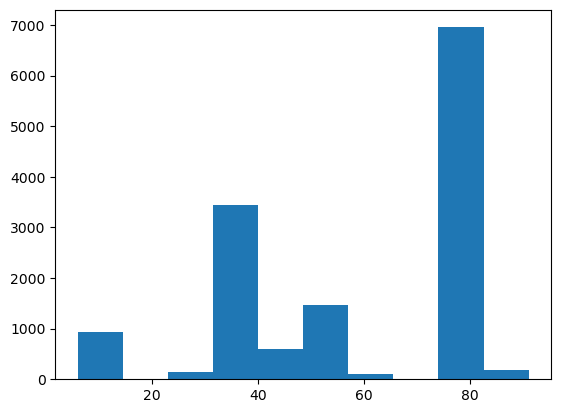

In [86]:
plt.hist(gdf['ridescore_v1'])

In [87]:
gdf.to_file('gdf_withScore_dcdata.geojson')

In [88]:
#value to scale

#lts to lts_score (already done)
gdf['lts_score'] = gdf['s_LTS']

#speed limit (if no value- speed is 25- too positive?)
def speedlimit_to_score(x):
    return 100-(2*x)
gdf["speedlimit_score"] = gdf["speed_limit"].map(speedlimit_to_score)

#number of lanes, blank goes to 10 score
def num_lanes_to_score(x): return {0:100, 1:100, 2:75, 3:50, 4:25, 5:25, 6:0, 7:0, 8:0, 10:0}.get(int(x), 10)
gdf["num_lanes_score"] = gdf["num_lanes_raw"].map(num_lanes_to_score)

#bike lanes
def facility_to_score(x): return {'protected_track':100, 'buffered_lane':75, 'painted_lane': 50, 'none': 0}.get(x, 0)
gdf["facility_score"] = gdf["bike_facility_type"].map(facility_to_score)

#road type
def function_to_score(x): return {'Local': 100, 'Collector': 75, 'Minor Arterial':50, 
       'Principal/Primary Arterial':25, 'Other Freeway and Expressway': 0,
       'Interstate':0, 'Other':0}.get(x, 0)
gdf["function_score"] = gdf["function"].map(function_to_score)

#road width
def road_width_to_score(x):
    return 100-x
gdf["road_width_score"] = gdf["road_width"].map(road_width_to_score)

#slow street- seems to have ended in 2021

#pavement condition
def pavement_condition_to_score(x): return {'Excellent': 100, 'Good': 75, 'Fair':50, 
       'Poor':25,'Very Poor': 0}.get(x, 50)
gdf["pavement_condition_score"] = gdf["pavement_condition"].map(pavement_condition_to_score)

gdf[['pavement_condition', 'pavement_condition_score']]

,pavement_condition,pavement_condition_score
0,Excellent,100
1,Excellent,100
2,Good,75
3,None,50
4,Excellent,100
...,...,...
13833,Poor,25
13834,Excellent,100
13835,Good,75
13836,Excellent,100


In [89]:
# 10A) Build a lean render GeoDataFrame

# === knobs you can tweak ===
SIMPLIFY_TOL_M   = 4      # simplify by ~4 meters
ROUND_COORDS     = 5      # round lon/lat (~1 m)
MIN_LENGTH_M     = 8      # drop tiny segments
KEEP_FIELDS      = gdf.columns       # keep all
#["crash_count_5yr","parking_presence","num_lanes_raw", "speed_limit_raw", "bike_facility_type", "route_id", "lts_level", "ridescore_v1", "geometry"]
#["segment_id", "lts_level", "ridescore_v1", "geometry"]
FILTER_SCORE_MIN = None   # e.g., 20
FILTER_SCORE_MAX = None   # e.g., 80

# Start from the scored 'gdf' produced in cell 10
render = gdf[KEEP_FIELDS].copy()

# Optional score filters
if FILTER_SCORE_MIN is not None:
    render = render[render["ridescore_v1"] >= float(FILTER_SCORE_MIN)]
if FILTER_SCORE_MAX is not None:
    render = render[render["ridescore_v1"] <= float(FILTER_SCORE_MAX)]

# Drop duplicate geometries
render["_wkb"] = render.geometry.apply(lambda geom: geom.wkb)
render = render.drop_duplicates("_wkb").drop(columns="_wkb")

# Drop very short segments
rp = render.to_crs(3857)
render = render[rp.length >= MIN_LENGTH_M].copy()

# Simplify then return to WGS84
rp = render.to_crs(3857)
rp["geometry"] = rp.geometry.simplify(SIMPLIFY_TOL_M, preserve_topology=True)
render = rp.to_crs(4326)

# Round coordinates
from shapely.geometry import LineString
def round_linestring(ls, n=ROUND_COORDS):
    #print(ls)
    coords = [(round(x, n), round(y, n), z) for x, y, z in ls.coords]
    return LineString(coords)

render["geometry"] = render.geometry.apply(lambda g: round_linestring(g, ROUND_COORDS))
print("Render features:", len(render))
render.head(2)

Render features: 13834


,route_id,route_name,function,num_lanes,num_lanes_raw,speed_limit,speed_limit_raw,bike_facility_type,parking_presence,road_width,...,s_crash,s_facility,ridescore_v1,lts_score,speedlimit_score,num_lanes_score,facility_score,function_score,road_width_score,pavement_condition_score
0,11064022,NEVADA AVE NW,Collector,2,2,20.0,20.0,none,True,33,...,100.0,0,36.0,10,60.0,75,0,75,67,100
1,11001002,10TH ST NW,Collector,1,1,25.0,NaN,painted_lane,True,31,...,100.0,3,75.3,75,50.0,100,50,75,69,100


In [90]:
render['parking_presence'] = render['parking_presence'].astype(int)

In [91]:
render.to_file('render_dcdata_wCrashes.geojson')

In [92]:
render_wkt = render.copy()
render_wkt = render_wkt.drop(columns = 'geometry')
render_wkt.to_csv('render_dc_data_wCrashes.csv')